# CSCI E-89 Assignment 03 — Problem 5

**Susana Waiha S. Fox**

This notebook first reproduces the assignment reference MLP, then compares a compact CNN that preserves image structure. Both models use the same fixed split and validation-only model selection. The test set remains separate and is not consulted during training or comparison.

## Load FashionMNIST and make deterministic data loaders

This cell corresponds to `prob5_codex/01_data_setup.py`.

In [1]:
"""Load FashionMNIST and create seeded, separate train, validation and test loaders."""
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

SEED = 42
BATCH_SIZE = 64

def setup_data(root="datasets"):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
    combined = torchvision.datasets.FashionMNIST(root=root, train=True, download=True, transform=transform)
    test_data = torchvision.datasets.FashionMNIST(root=root, train=False, download=True, transform=transform)
    generator = torch.Generator().manual_seed(SEED)
    train_data, valid_data = torch.utils.data.random_split(combined, [55_000, 5_000], generator=generator)
    shuffle_generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, generator=shuffle_generator)
    train_eval_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False)
    valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
    return combined, train_data, valid_data, test_data, train_loader, train_eval_loader, valid_loader, test_loader

if __name__ == "__main__":
    data = setup_data()
    print(f"Train: {len(data[1]):,}; validation: {len(data[2]):,}; test: {len(data[3]):,}")


Train: 55,000; validation: 5,000; test: 10,000


## Define the reference MLP and a compact convolutional model

This cell corresponds to `prob5_codex/02_model.py`.

In [2]:
"""Define the reference MLP and a compact CNN comparison model."""
import torch.nn as nn

class ImageClassifier(nn.Module):
    """Assignment reference architecture: 784→300→100→10."""
    def __init__(self, n_inputs=784, n_hidden1=300, n_hidden2=100, n_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2), nn.ReLU(),
            nn.Linear(n_hidden2, n_classes),
        )

    def forward(self, images):
        return self.mlp(images)

class FashionCNN(nn.Module):
    """Small CNN that retains the 2D structure of grayscale images."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(p=0.25),
            nn.Linear(128, n_classes),
        )

    def forward(self, images):
        return self.classifier(self.features(images))


## Add reproducible training, separate evaluation, loss tracking, momentum SGD, a learning-rate scheduler, and early stopping

This cell corresponds to `prob5_codex/03_train_model.py`.

In [3]:
"""Train/evaluate models with deterministic settings, losses, momentum and plateau scheduling."""
import json
import random
from pathlib import Path
import numpy as np
import torch
from torch import nn

SEED = 42
EPOCHS = 20
LEARNING_RATE = 0.05
WEIGHT_DECAY = 1e-4
PATIENCE = 5

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

def evaluate_model(model, loader, loss_fn, device):
    """Evaluate loss and accuracy in eval mode without gradient tracking."""
    model.eval()
    loss_sum = 0.0
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss_sum += loss_fn(logits, labels).item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, correct / total

def train_model(model, train_loader, train_eval_loader, valid_loader,
                model_name="mlp", epochs=EPOCHS, learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                output_dir="artifacts"):
    seed_everything(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(), lr=learning_rate, momentum=0.9,
        weight_decay=weight_decay, nesterov=True
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, min_lr=0.001
    )
    history = {"model": model_name, "seed": SEED, "epochs_requested": epochs,
               "learning_rate": learning_rate, "momentum": 0.9,
               "weight_decay": weight_decay, "train_loss": [],
               "train_accuracy": [], "valid_loss": [], "valid_accuracy": [],
               "learning_rates": []}
    best_loss = float("inf")
    best_weights = None
    epochs_without_improvement = 0
    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        seen = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(images), labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * labels.size(0)
            seen += labels.size(0)
        train_loss, train_acc = evaluate_model(model, train_eval_loader, loss_fn, device)
        valid_loss, valid_acc = evaluate_model(model, valid_loader, loss_fn, device)
        scheduler.step(valid_loss)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_accuracy"].append(valid_acc)
        history["learning_rates"].append(optimizer.param_groups[0]["lr"])
        print(f"{model_name} epoch {epoch + 1:02d}/{epochs}: "
              f"train loss={train_loss:.4f}, accuracy={train_acc:.4f}; "
              f"validation loss={valid_loss:.4f}, accuracy={valid_acc:.4f}; "
              f"lr={optimizer.param_groups[0]['lr']:.4g}")
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_weights = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping after epoch {epoch + 1}; best validation loss={best_loss:.4f}.")
                break
    model.load_state_dict(best_weights)
    best_epoch = min(range(len(history["valid_loss"])), key=history["valid_loss"].__getitem__)
    history["best_epoch"] = best_epoch + 1
    history["best_valid_loss"] = history["valid_loss"][best_epoch]
    history["best_valid_accuracy"] = history["valid_accuracy"][best_epoch]
    history["final_train_loss"] = history["train_loss"][best_epoch]
    history["final_train_accuracy"] = history["train_accuracy"][best_epoch]
    output = Path(output_dir)
    output.mkdir(parents=True, exist_ok=True)
    torch.save({"model_state_dict": model.state_dict(), "history": history}, output / f"prob5_{model_name}_checkpoint.pt")
    (output / f"prob5_{model_name}_history.json").write_text(json.dumps(history, indent=2) + "\n")
    return model, history, device


## Plot training and validation accuracy for both models

This cell corresponds to `prob5_codex/04_plot_training_accuracy.py`.

In [4]:
"""Plot training and validation accuracy by epoch for model comparison."""
from pathlib import Path
import matplotlib.pyplot as plt

def plot_training_accuracy(histories, output_path="artifacts/prob5_training_accuracy.png"):
    if isinstance(histories, dict):
        histories = [histories]
    fig, ax = plt.subplots(figsize=(9, 5))
    for history in histories:
        epochs = range(1, len(history["train_accuracy"]) + 1)
        label = history["model"].upper()
        ax.plot(epochs, history["train_accuracy"], marker=".", label=f"{label} training")
        ax.plot(epochs, history["valid_accuracy"], marker=".", linestyle="--", label=f"{label} validation")
    ax.set(title="FashionMNIST Accuracy by Epoch", xlabel="Epoch", ylabel="Accuracy")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2)
    fig.tight_layout()
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150)
    plt.show()
    return fig


## Show seeded example predictions from the validation set

This cell corresponds to `prob5_codex/05_predict_examples.py`.

In [5]:
"""Show seeded random examples with predicted and true class labels."""
import matplotlib.pyplot as plt
import torch

def show_example_predictions(model, dataset, class_names, device, count=6, seed=42):
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:min(count, len(dataset))].tolist()
    examples = [dataset[index] for index in indices]
    images, labels = zip(*examples)
    batch = torch.stack(images).to(device)
    with torch.no_grad():
        predictions = model(batch).argmax(dim=1).cpu().tolist()
    fig, axes = plt.subplots(1, len(indices), figsize=(2.2 * len(indices), 3), squeeze=False)
    for ax, image, label, prediction in zip(axes[0], images, labels, predictions):
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(f"Pred: {class_names[prediction]}\nTrue: {class_names[label]}")
        ax.axis("off")
    fig.tight_layout()
    plt.show()
    return fig, predictions


## Load the data

A fixed seed determines the 55,000/5,000 split and training batch order. The 10,000 test images are held out. A separate non-shuffling loader provides a stable training metric after each epoch.

In [6]:
combined, train_data, valid_data, test_data, train_loader, train_eval_loader, valid_loader, test_loader = setup_data()
class_names = combined.classes
print(f"Train: {len(train_data):,}; validation: {len(valid_data):,}; held-out test: {len(test_data):,}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'MPS' if torch.backends.mps.is_available() else 'CPU'}; PyTorch {torch.__version__}")

Train: 55,000; validation: 5,000; held-out test: 10,000
Device: MPS; PyTorch 2.14.0


## Train the assignment reference MLP

Use the specified 784→300→100→10 MLP. The improved training setup uses momentum SGD, weight decay, validation-loss scheduling, and early stopping. The same training setup is used for the CNN comparison.

For a fast, reproducible CPU demonstration, the next comparison uses a seeded 12,000-image subset sampled from the training partition only. Validation remains the full 5,000-image validation partition. The scripts retain defaults for training on the complete training partition.

In [7]:
subset_generator = torch.Generator().manual_seed(42)
train_subset, _ = torch.utils.data.random_split(train_data, [12_000, len(train_data) - 12_000], generator=subset_generator)
train_subset_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(42))
train_subset_eval_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=False)
print(f"Training subset used for this CPU demonstration: {len(train_subset):,} of {len(train_data):,}")

Training subset used for this CPU demonstration: 12,000 of 55,000


In [8]:
mlp_model = ImageClassifier()
mlp_model, mlp_history, device = train_model(mlp_model, train_subset_loader, train_subset_eval_loader, valid_loader, model_name="mlp", epochs=6)

mlp epoch 01/6: train loss=0.5244, accuracy=0.8118; validation loss=0.5457, accuracy=0.8124; lr=0.05


mlp epoch 02/6: train loss=0.4278, accuracy=0.8397; validation loss=0.4843, accuracy=0.8158; lr=0.05


mlp epoch 03/6: train loss=0.3727, accuracy=0.8652; validation loss=0.4509, accuracy=0.8408; lr=0.05


mlp epoch 04/6: train loss=0.3635, accuracy=0.8610; validation loss=0.4348, accuracy=0.8358; lr=0.05


mlp epoch 05/6: train loss=0.3274, accuracy=0.8842; validation loss=0.4180, accuracy=0.8532; lr=0.05


mlp epoch 06/6: train loss=0.3548, accuracy=0.8677; validation loss=0.4727, accuracy=0.8308; lr=0.05


## Train a compact CNN comparison

The CNN uses two convolution and pooling stages followed by a small classifier. It retains the images’ 2D structure. Validation loss controls the learning-rate schedule, early stopping, and best checkpoint selection.

In [9]:
cnn_model = FashionCNN()
cnn_model, cnn_history, device = train_model(cnn_model, train_subset_loader, train_subset_eval_loader, valid_loader, model_name="cnn", epochs=6)

cnn epoch 01/6: train loss=0.4733, accuracy=0.8343; validation loss=0.5044, accuracy=0.8246; lr=0.05


cnn epoch 02/6: train loss=0.3676, accuracy=0.8674; validation loss=0.4109, accuracy=0.8552; lr=0.05


cnn epoch 03/6: train loss=0.3153, accuracy=0.8828; validation loss=0.3822, accuracy=0.8578; lr=0.05


cnn epoch 04/6: train loss=0.2727, accuracy=0.8958; validation loss=0.3469, accuracy=0.8720; lr=0.05


cnn epoch 05/6: train loss=0.2427, accuracy=0.9086; validation loss=0.3498, accuracy=0.8780; lr=0.05


cnn epoch 06/6: train loss=0.2225, accuracy=0.9156; validation loss=0.3430, accuracy=0.8782; lr=0.05


## Compare learning curves

The plot includes training and validation accuracy for both models. Use validation results for model comparison; do not use the held-out test set to select between them.

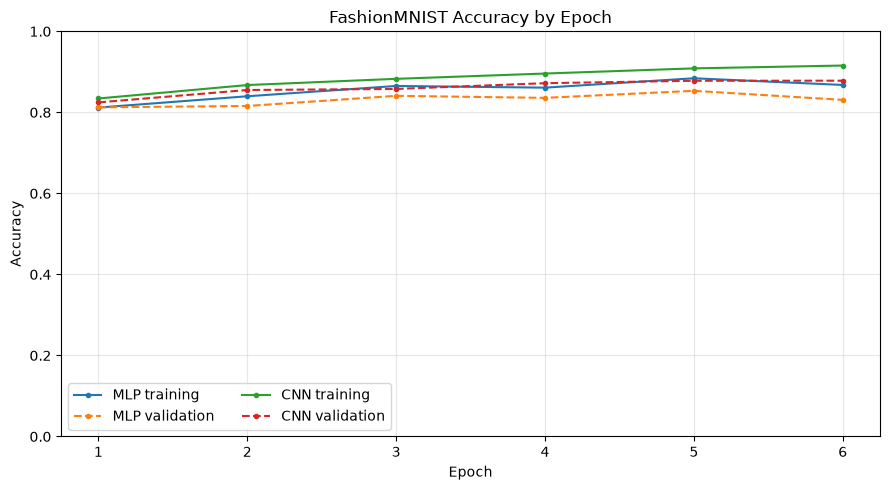

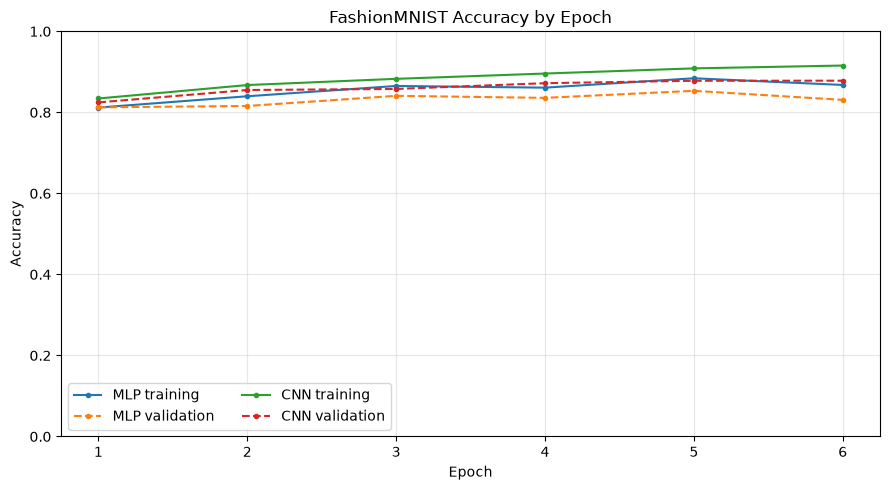

In [10]:
plot_training_accuracy([mlp_history, cnn_history])

## Compare best validation results

The best checkpoint for each model is selected by validation loss. These results are still validation estimates, not test performance.

In [11]:
for result in (mlp_history, cnn_history):
    print(f"{result['model'].upper()}: best epoch {result['best_epoch']}, "
          f"train accuracy={result['final_train_accuracy']:.4f}, "
          f"validation accuracy={result['best_valid_accuracy']:.4f}, "
          f"validation loss={result['best_valid_loss']:.4f}")

MLP: best epoch 5, train accuracy=0.8842, validation accuracy=0.8532, validation loss=0.4180
CNN: best epoch 6, train accuracy=0.9156, validation accuracy=0.8782, validation loss=0.3430


## Inspect seeded validation predictions

Show a fixed random selection of validation examples from the better validation-loss checkpoint for qualitative inspection. The test set remains untouched.

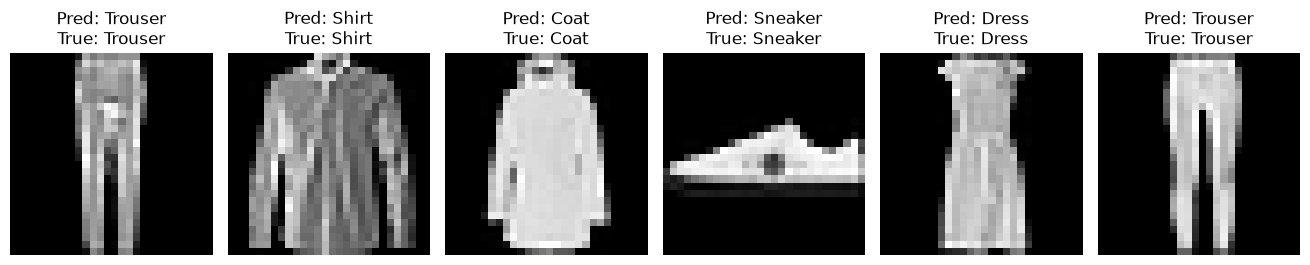

Displayed 6 CNN predictions from validation data.


In [12]:
best_model, best_history = (cnn_model, cnn_history) if cnn_history["best_valid_loss"] < mlp_history["best_valid_loss"] else (mlp_model, mlp_history)
fig, predictions = show_example_predictions(best_model, valid_data, class_names, device)
print(f"Displayed {len(predictions)} {best_history['model'].upper()} predictions from validation data.")

## Reflection and limitations

The reference MLP remains the assignment baseline. The CNN is a validation-based comparison that may improve classification by preserving image structure. The reported training metric is calculated with a non-shuffling evaluation loader, while validation loss determines scheduling, early stopping, and checkpoint selection. The test set has not been evaluated; for an unbiased final estimate, evaluate the selected model on it once after all choices are fixed.